# 01_2 EfficientTeacher Single-Client Evaluation

Read-only analysis for the single-client EfficientTeacher run. It summarizes training curves, pseudo-label quality/counts, paper-protocol validation, and optional comparisons against DQA/FedSTO artifacts when they exist.

In [1]:
print("hello world")

hello world


In [2]:
from __future__ import annotations

import json
import re
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as NotebookImage, display

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None


def find_repo_root(start: Optional[Path] = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    required = (
        "efficient_teacher/run_efficient_teacher_single_client.py",
        "navigating_data_heterogeneity/evaluate_paper_protocol.py",
    )
    candidates = []
    for base in (start, *start.parents):
        candidates.extend([base, base / "Object_Detection"])
    for candidate in candidates:
        if all((candidate / marker).exists() for marker in required):
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the Object_Detection repository root.")


REPO_ROOT = find_repo_root()
ET_ROOT = REPO_ROOT / "efficient_teacher"
WORK_ROOT = ET_ROOT / "efficientteacher_single_client"
LOCALEMA_WORK_ROOT = ET_ROOT / "efficientteacher_localema"
RUNS_ROOT = WORK_ROOT / "runs"
PSEUDO_STATS_ROOT = WORK_ROOT / "pseudo_stats"
VALIDATION_ROOT = WORK_ROOT / "validation_reports"
EVAL_SCRIPT = ET_ROOT / "evaluate_paper_protocol.py"
PYTHON_BIN = Path(sys.executable)
METHOD_WORKSPACES = {
    "EfficientTeacher-1C": WORK_ROOT,
    "LocalEMA-1C": LOCALEMA_WORK_ROOT,
}

DQA_PAPER_EVAL = (
    REPO_ROOT
    / "dynamic_quality_aware_classwise_aggregation"
    / "efficientteacher_dqa_cwa_corrected_12h"
    / "validation_reports"
    / "paper_protocol_eval_summary.csv"
)
FEDSTO_PAPER_EVAL = (
    REPO_ROOT
    / "navigating_data_heterogeneity"
    / "efficientteacher_fedsto"
    / "validation_reports"
    / "paper_protocol_eval_summary.csv"
)

if sns is not None:
    sns.set_theme(style="whitegrid", context="talk")
else:
    plt.style.use("ggplot")
pd.options.display.max_columns = 200
print("workspace:", WORK_ROOT)
print("localema workspace:", LOCALEMA_WORK_ROOT)

workspace: /app/Object_Detection/efficient_teacher/efficientteacher_single_client
localema workspace: /app/Object_Detection/efficient_teacher/efficientteacher_localema


## Stitched Server Metric Curves for 00 and 01

Warmup, phase1, and phase2 server validation metrics are plotted on one stitched timeline. This is the compact view for comparing 00 LocalEMA and 01 EfficientTeacher.


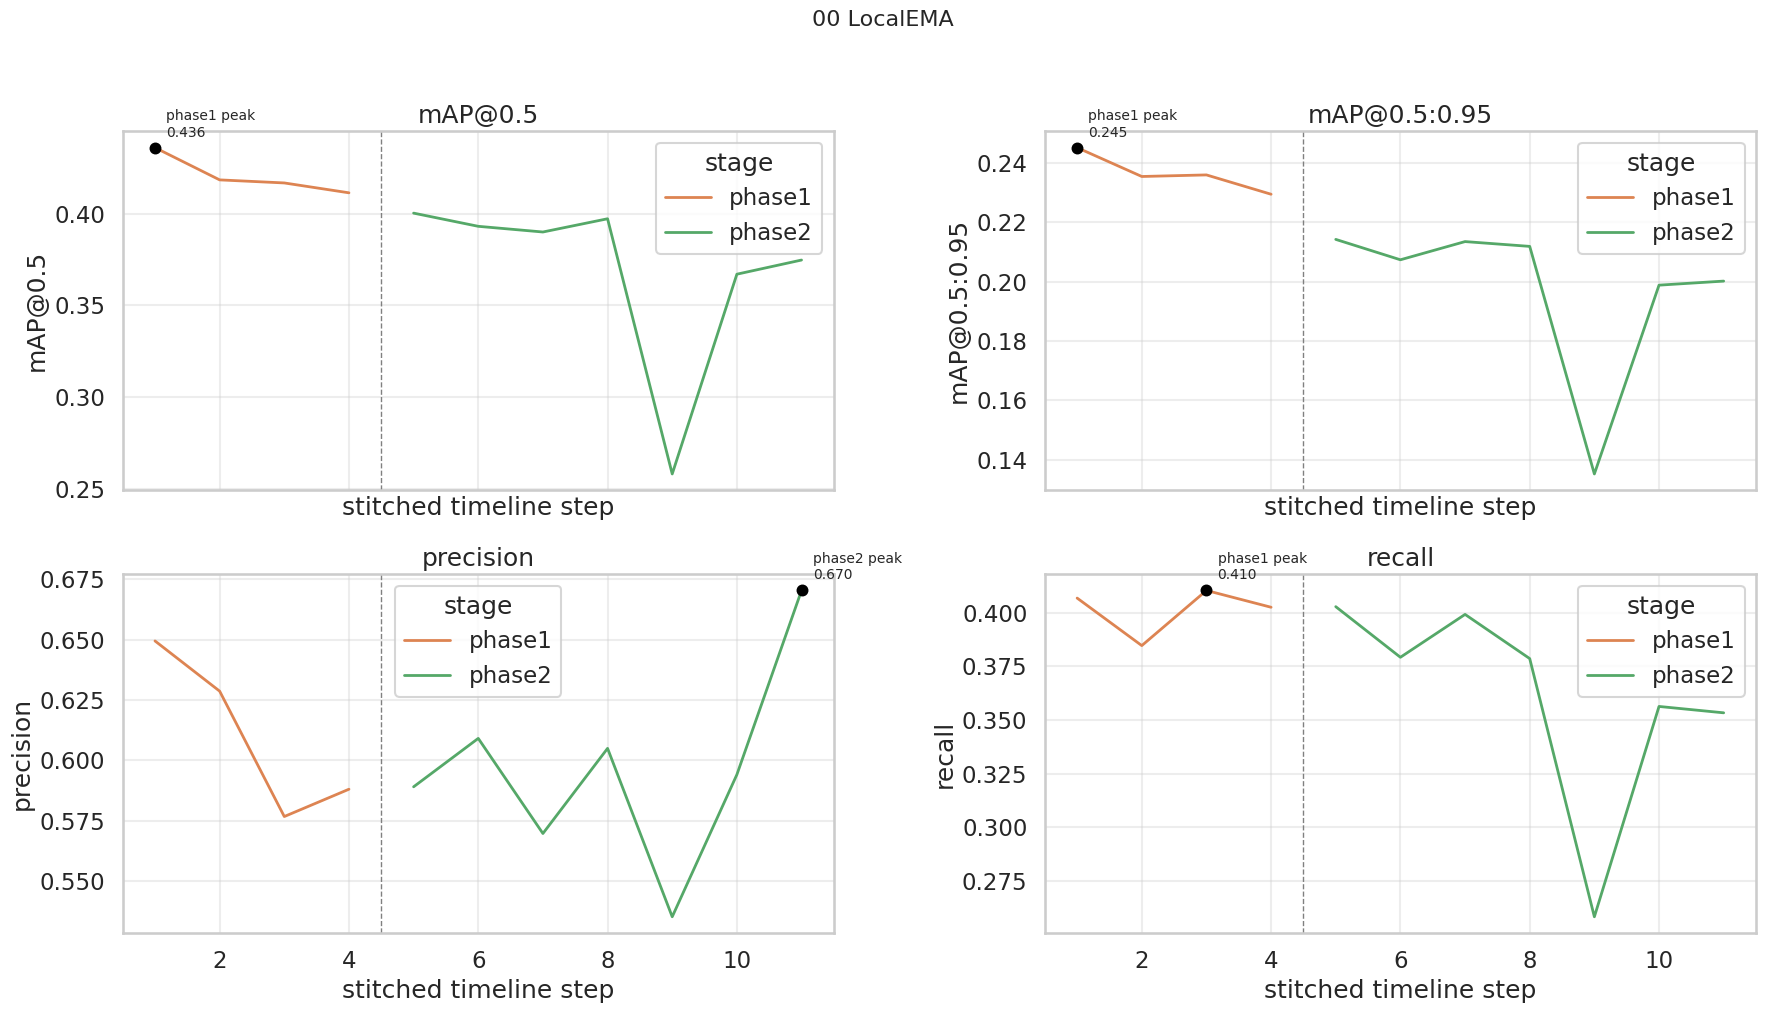

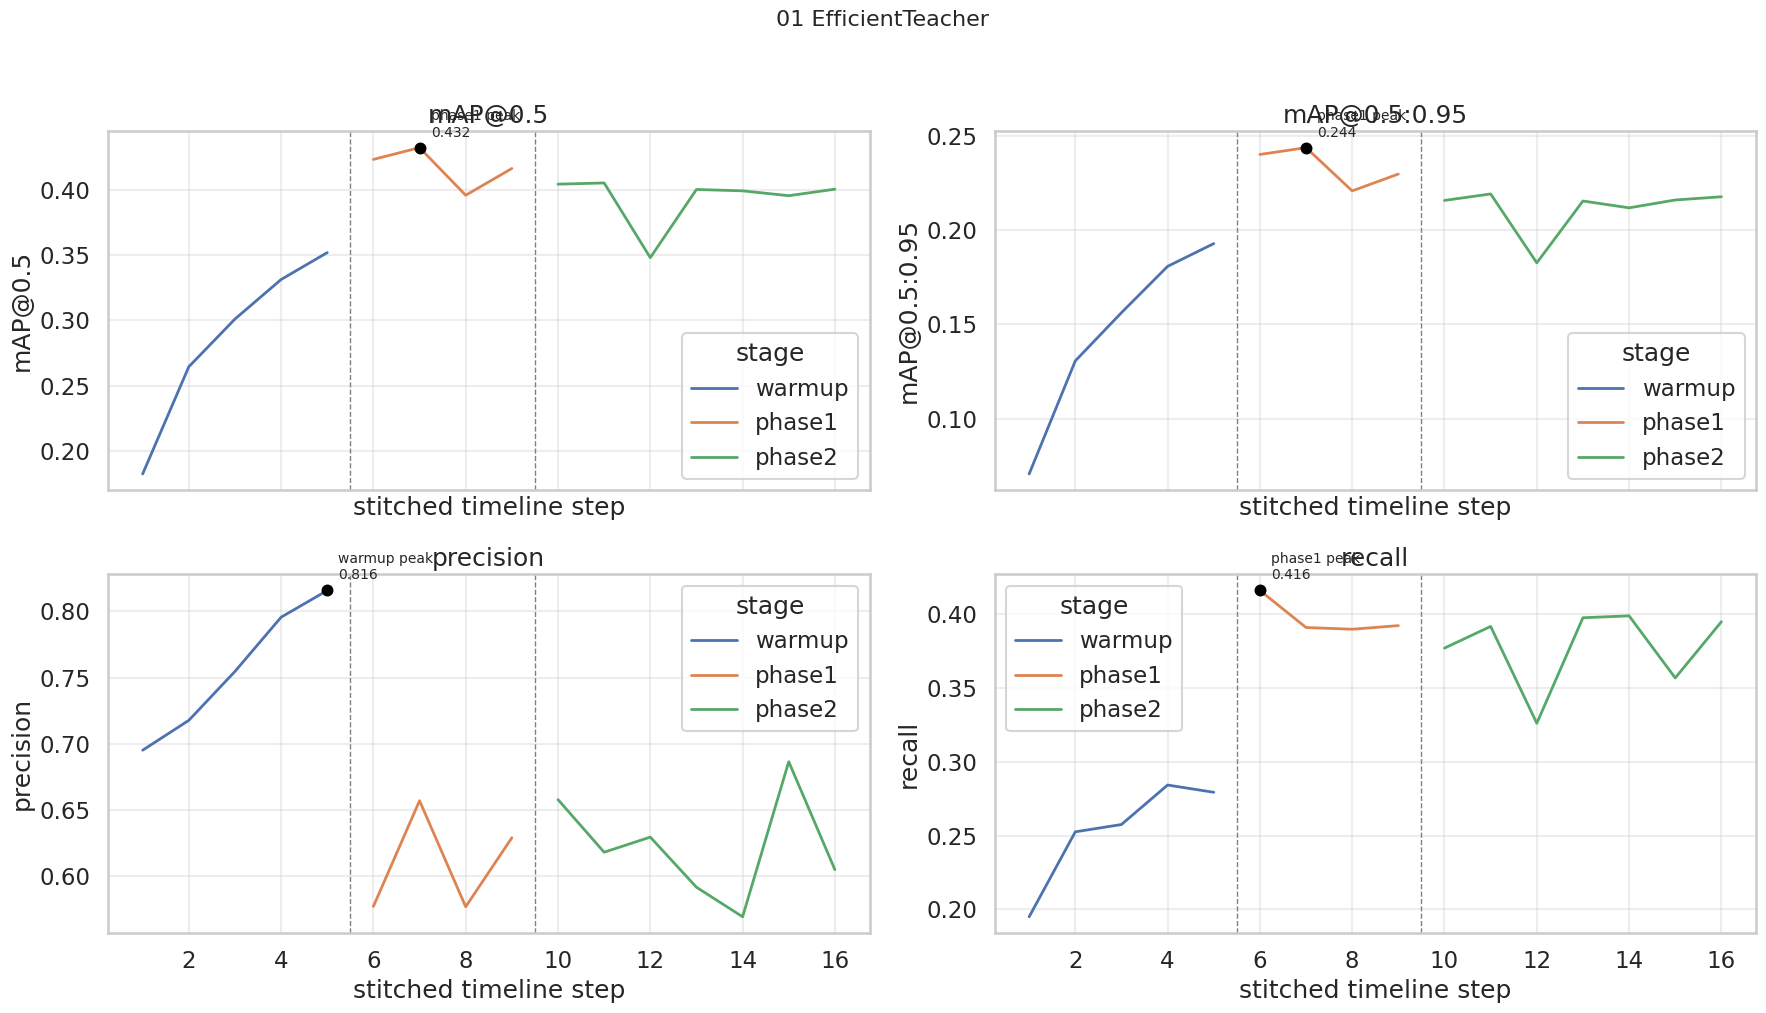

In [3]:
STITCHED_METHODS = {
    "00 LocalEMA": LOCALEMA_WORK_ROOT,
    "01 EfficientTeacher": WORK_ROOT,
}
STAGE_COLORS = {
    "warmup": "#4C72B0",
    "phase1": "#DD8452",
    "phase2": "#55A868",
}
SERVER_RUN_RE = re.compile(r"et_phase(?P<phase>[12])_round(?P<round>\d{3})_server")
METRIC_SPECS = [
    ("metrics/mAP_0.5", "mAP@0.5"),
    ("metrics/mAP_0.5:0.95", "mAP@0.5:0.95"),
    ("metrics/precision", "precision"),
    ("metrics/recall", "recall"),
]


def read_results_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, skipinitialspace=True).rename(columns=lambda col: col.strip())


def load_server_round_summary(workspace: Path) -> pd.DataFrame:
    rows = []
    for result_path in sorted((workspace / "runs").glob("et_phase*_round*_server/results.csv")):
        match = SERVER_RUN_RE.fullmatch(result_path.parent.name)
        if not match:
            continue
        df = read_results_csv(result_path)
        if df.empty:
            continue
        last = df.iloc[-1]
        row = {
            "phase": int(match.group("phase")),
            "round": int(match.group("round")),
        }
        for metric_col, _ in METRIC_SPECS:
            row[metric_col] = float(last.get(metric_col, np.nan))
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["phase", "round"]) if rows else pd.DataFrame()


def load_warmup_curve(workspace: Path) -> pd.DataFrame:
    warmup_path = workspace / "runs" / "runtime_server_warmup" / "results.csv"
    if not warmup_path.exists():
        return pd.DataFrame(columns=["timeline", "stage", *[metric for metric, _ in METRIC_SPECS]])
    df = read_results_csv(warmup_path)
    if df.empty:
        return pd.DataFrame(columns=["timeline", "stage", *[metric for metric, _ in METRIC_SPECS]])
    curve = df[["epoch", *[metric for metric, _ in METRIC_SPECS]]].copy()
    curve["timeline"] = curve["epoch"].astype(float) + 1
    curve["stage"] = "warmup"
    return curve[["timeline", "stage", *[metric for metric, _ in METRIC_SPECS]]]


def server_phase_curve(summary: pd.DataFrame, phase: int, stage: str, offset: int) -> pd.DataFrame:
    if summary.empty:
        return pd.DataFrame(columns=["timeline", "stage", "round", *[metric for metric, _ in METRIC_SPECS]])
    phase_df = summary[summary["phase"].eq(phase)].copy()
    if phase_df.empty:
        return pd.DataFrame(columns=["timeline", "stage", "round", *[metric for metric, _ in METRIC_SPECS]])
    phase_df["timeline"] = offset + phase_df["round"]
    phase_df["stage"] = stage
    return phase_df[["timeline", "stage", "round", *[metric for metric, _ in METRIC_SPECS]]]


def stitched_server_curve(workspace: Path) -> tuple[pd.DataFrame, int, int]:
    warmup = load_warmup_curve(workspace)
    warmup_steps = int(warmup["timeline"].max()) if not warmup.empty else 0
    summary = load_server_round_summary(workspace)
    phase1_steps = int(summary.loc[summary["phase"].eq(1), "round"].max()) if not summary.empty and summary["phase"].eq(1).any() else 0
    curve = pd.concat(
        [
            warmup,
            server_phase_curve(summary, 1, "phase1", warmup_steps),
            server_phase_curve(summary, 2, "phase2", warmup_steps + phase1_steps),
        ],
        ignore_index=True,
    )
    return curve, warmup_steps, phase1_steps


def plot_stage_line(ax, data: pd.DataFrame, metric_col: str) -> None:
    data = data.dropna(subset=[metric_col]).copy()
    if data.empty:
        return
    for stage in ["warmup", "phase1", "phase2"]:
        part = data[data["stage"].eq(stage)]
        if part.empty:
            continue
        ax.plot(part["timeline"], part[metric_col], color=STAGE_COLORS[stage], linewidth=2, label=stage)


def plot_stitched_metrics(method: str, workspace: Path) -> None:
    curve, warmup_steps, phase1_steps = stitched_server_curve(workspace)
    if curve.empty:
        print(f"{method}: no server metric results found in {workspace}")
        return

    fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)
    fig.suptitle(method, fontsize=16, y=1.02)

    for ax, (metric_col, title) in zip(axes.flat, METRIC_SPECS):
        plot_stage_line(ax, curve, metric_col)
        if warmup_steps:
            ax.axvline(warmup_steps + 0.5, color="gray", linestyle="--", linewidth=1)
        if phase1_steps:
            ax.axvline(warmup_steps + phase1_steps + 0.5, color="gray", linestyle="--", linewidth=1)

        valid = curve.dropna(subset=[metric_col])
        if not valid.empty:
            best_idx = valid[metric_col].astype(float).idxmax()
            best_row = valid.loc[best_idx]
            ax.scatter([best_row["timeline"]], [best_row[metric_col]], color="black", s=50, zorder=5)
            ax.annotate(
                f"{best_row['stage']} peak\n{best_row[metric_col]:.3f}",
                (best_row["timeline"], best_row[metric_col]),
                textcoords="offset points",
                xytext=(8, 8),
                fontsize=10,
            )

        ax.set_title(title)
        ax.set_xlabel("stitched timeline step")
        ax.set_ylabel(title)
        ax.grid(True, alpha=0.35)
        ax.legend(title="stage", loc="best")

    plt.tight_layout()
    plt.show()


for method, workspace in STITCHED_METHODS.items():
    plot_stitched_metrics(method, workspace)

## 1. Artifact Status

In [4]:
def modified_utc(path: Path) -> str:
    if not path.exists():
        return ""
    return datetime.fromtimestamp(path.stat().st_mtime, tz=timezone.utc).isoformat()


manifest_path = WORK_ROOT / "manifest.json"
history_path = WORK_ROOT / "history.json"
manifest = json.loads(manifest_path.read_text(encoding="utf-8")) if manifest_path.exists() else {}
history = json.loads(history_path.read_text(encoding="utf-8")) if history_path.exists() else []

artifacts = []
for method, workspace in METHOD_WORKSPACES.items():
    artifacts.extend(
        [
            (method, "workspace", workspace),
            (method, "manifest", workspace / "manifest.json"),
            (method, "history", workspace / "history.json"),
            (method, "runs", workspace / "runs"),
            (method, "pseudo_stats", workspace / "pseudo_stats"),
            (method, "global_checkpoints", workspace / "global_checkpoints"),
            (method, "paper_eval_summary", workspace / "validation_reports" / "paper_protocol_eval_summary.csv"),
        ]
    )
display(
    pd.DataFrame(
        [
            {
                "method": method,
                "artifact": label,
                "path": str(path),
                "exists": path.exists(),
                "modified_utc": modified_utc(path),
            }
            for method, label, path in artifacts
        ]
    )
)

if manifest:
    display(
        pd.DataFrame(
            [
                {
                    "server_train_images": manifest["server"]["train_images"],
                    "server_val_images": manifest["server"]["val_images"],
                    "client": manifest["clients"][0]["weather"] if manifest.get("clients") else "",
                    "client_images": manifest["clients"][0]["images"] if manifest.get("clients") else "",
                }
            ]
        )
    )
display(pd.DataFrame(history).tail(12) if history else pd.DataFrame())

,method,artifact,path,exists,modified_utc
0,EfficientTeacher-1C,workspace,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T08:52:43.443973+00:00
1,EfficientTeacher-1C,manifest,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T08:52:40.762985+00:00
2,EfficientTeacher-1C,history,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T09:29:42.429777+00:00
3,EfficientTeacher-1C,runs,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T09:27:05.477498+00:00
4,EfficientTeacher-1C,pseudo_stats,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T09:26:56.674538+00:00
5,EfficientTeacher-1C,global_checkpoints,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T09:29:42.433777+00:00
6,EfficientTeacher-1C,paper_eval_summary,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T06:57:06.232850+00:00
7,LocalEMA-1C,workspace,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T07:15:16.963838+00:00
8,LocalEMA-1C,manifest,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T07:15:15.017847+00:00
9,LocalEMA-1C,history,/app/Object_Detection/efficient_teacher/effici...,True,2026-04-27T07:47:38.481917+00:00


,server_train_images,server_val_images,client,client_images
0,4881,738,overcast,5000


,phase,round,global,protocol
0,1,1,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_no_...
1,1,2,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_no_...
2,1,3,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_no_...
3,1,4,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_no_...
4,2,1,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_pha...
5,2,2,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_pha...
6,2,3,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_pha...
7,2,4,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_pha...
8,2,5,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_pha...
9,2,6,/app/Object_Detection/efficient_teacher/effici...,efficientteacher_single_client_dqa_matched_pha...


## 2. Training Summary Table

In [5]:
def parse_run_name(run_name: str) -> dict:
    if run_name == "runtime_server_warmup":
        return {"phase": 0, "round": 0, "role": "warmup", "client_id": np.nan, "weather": "server_cloudy"}
    match = re.fullmatch(
        r"et_phase(?P<phase>[12])_round(?P<round>\d{3})_(?P<role>server|client(?P<client_id>\d+)_(?P<weather>.+))",
        run_name,
    )
    if not match:
        return {"phase": np.nan, "round": np.nan, "role": "unknown", "client_id": np.nan, "weather": ""}
    role = "client" if match.group("role").startswith("client") else "server"
    return {
        "phase": int(match.group("phase")),
        "round": int(match.group("round")),
        "role": role,
        "client_id": int(match.group("client_id")) if match.group("client_id") else np.nan,
        "weather": match.group("weather") or "server_cloudy",
    }


def load_results() -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    summary_rows = []
    for result_path in sorted(RUNS_ROOT.glob("*/results.csv")):
        run_name = result_path.parent.name
        df = pd.read_csv(result_path, skipinitialspace=True).rename(columns=lambda col: col.strip())
        if df.empty:
            continue
        meta = parse_run_name(run_name)
        for _, row in df.iterrows():
            rows.append({"run_name": run_name, **meta, **row.to_dict()})
        last = df.iloc[-1].to_dict()
        best_idx = df["metrics/mAP_0.5"].astype(float).idxmax() if "metrics/mAP_0.5" in df else df.index[-1]
        best = df.loc[best_idx].to_dict()
        summary_rows.append(
            {
                "run_name": run_name,
                **meta,
                "epochs_logged": len(df),
                "final_epoch": last.get("epoch"),
                "final_precision": last.get("metrics/precision"),
                "final_recall": last.get("metrics/recall"),
                "final_map50": last.get("metrics/mAP_0.5"),
                "final_map50_95": last.get("metrics/mAP_0.5:0.95"),
                "best_map50": best.get("metrics/mAP_0.5"),
                "best_map50_epoch": best.get("epoch"),
                "train_box_loss": last.get("train/box_loss"),
                "train_obj_loss": last.get("train/obj_loss"),
                "train_cls_loss": last.get("train/cls_loss"),
            }
        )
    return pd.DataFrame(rows), pd.DataFrame(summary_rows)


results_df, summary_df = load_results()
tables_root = VALIDATION_ROOT / "tables"
tables_root.mkdir(parents=True, exist_ok=True)
if not summary_df.empty:
    summary_df = summary_df.sort_values(["phase", "round", "role", "run_name"])
    summary_df.to_csv(tables_root / "training_run_summary.csv", index=False)
    display(summary_df.tail(20).round(4))
else:
    print("No results.csv files found yet.")

,run_name,phase,round,role,client_id,weather,epochs_logged,final_epoch,final_precision,final_recall,final_map50,final_map50_95,best_map50,best_map50_epoch,train_box_loss,train_obj_loss,train_cls_loss
2,et_phase1_round002_client0_overcast,1,2,client,0.0,overcast,1,0.0,0.5874,0.3052,0.3289,0.1886,0.3289,0.0,0.0000,0.0000,0.0000
3,et_phase1_round002_server,1,2,server,NaN,server_cloudy,1,0.0,0.6569,0.3910,0.4320,0.2436,0.4320,0.0,0.0375,0.0396,0.0051
4,et_phase1_round003_client0_overcast,1,3,client,0.0,overcast,1,0.0,0.1386,0.0063,0.0719,0.0405,0.0719,0.0,0.0000,0.0000,0.0000
5,et_phase1_round003_server,1,3,server,NaN,server_cloudy,1,0.0,0.5768,0.3898,0.3956,0.2207,0.3956,0.0,0.0378,0.0401,0.0051
6,et_phase1_round004_client0_overcast,1,4,client,0.0,overcast,1,0.0,0.5194,0.2668,0.2578,0.1474,0.2578,0.0,0.0000,0.0000,0.0000
7,et_phase1_round004_server,1,4,server,NaN,server_cloudy,1,0.0,0.6289,0.3923,0.4161,0.2297,0.4161,0.0,0.0362,0.0370,0.0045
8,et_phase2_round001_client0_overcast,2,1,client,0.0,overcast,2,0.0,0.5105,0.2877,0.2778,0.1131,0.2778,0.0,0.0000,0.0000,0.0000
9,et_phase2_round001_server,2,1,server,NaN,server_cloudy,2,0.0,0.6578,0.3770,0.4041,0.2157,0.4041,0.0,0.0417,0.0388,0.0047
10,et_phase2_round002_client0_overcast,2,2,client,0.0,overcast,1,0.0,0.4944,0.2915,0.2690,0.1228,0.2690,0.0,0.0000,0.0000,0.0000
11,et_phase2_round002_server,2,2,server,NaN,server_cloudy,1,0.0,0.6180,0.3917,0.4050,0.2191,0.4050,0.0,0.0403,0.0366,0.0044


## 3. ET vs LocalEMA Training Summary

In [6]:
def load_results_for_workspace(workspace: Path, method: str) -> pd.DataFrame:
    rows = []
    for result_path in sorted((workspace / "runs").glob("*/results.csv")):
        run_name = result_path.parent.name
        df = pd.read_csv(result_path, skipinitialspace=True).rename(columns=lambda col: col.strip())
        if df.empty:
            continue
        meta = parse_run_name(run_name)
        last = df.iloc[-1].to_dict()
        best_idx = df["metrics/mAP_0.5"].astype(float).idxmax() if "metrics/mAP_0.5" in df else df.index[-1]
        best = df.loc[best_idx].to_dict()
        rows.append(
            {
                "method": method,
                "workspace": str(workspace),
                "run_name": run_name,
                **meta,
                "epochs_logged": len(df),
                "final_precision": last.get("metrics/precision"),
                "final_recall": last.get("metrics/recall"),
                "final_map50": last.get("metrics/mAP_0.5"),
                "final_map50_95": last.get("metrics/mAP_0.5:0.95"),
                "best_map50": best.get("metrics/mAP_0.5"),
                "train_box_loss": last.get("train/box_loss"),
                "train_obj_loss": last.get("train/obj_loss"),
                "train_cls_loss": last.get("train/cls_loss"),
            }
        )
    return pd.DataFrame(rows)


method_summaries = [load_results_for_workspace(workspace, method) for method, workspace in METHOD_WORKSPACES.items()]
method_summary_df = pd.concat([df for df in method_summaries if not df.empty], ignore_index=True) if any(
    not df.empty for df in method_summaries
) else pd.DataFrame()
if not method_summary_df.empty:
    method_summary_df["timeline"] = np.where(
        method_summary_df["phase"] == 0,
        0,
        method_summary_df["phase"].astype(float) * 1000 + method_summary_df["round"].astype(float),
    )
    display(method_summary_df.sort_values(["method", "phase", "round", "role"]).tail(30).round(4))
else:
    print("No ET/LocalEMA training summaries found yet.")

,method,workspace,run_name,phase,round,role,client_id,weather,epochs_logged,final_precision,final_recall,final_map50,final_map50_95,best_map50,train_box_loss,train_obj_loss,train_cls_loss,timeline
14,EfficientTeacher-1C,/app/Object_Detection/efficient_teacher/effici...,et_phase2_round004_client0_overcast,2,4,client,0.0,overcast,1,0.5126,0.2537,0.2563,0.1104,0.2563,0.0000,0.0000,0.0000,2004.0
15,EfficientTeacher-1C,/app/Object_Detection/efficient_teacher/effici...,et_phase2_round004_server,2,4,server,NaN,server_cloudy,1,0.5915,0.3976,0.4000,0.2154,0.4000,0.0397,0.0351,0.0042,2004.0
16,EfficientTeacher-1C,/app/Object_Detection/efficient_teacher/effici...,et_phase2_round005_client0_overcast,2,5,client,0.0,overcast,1,0.1464,0.0056,0.0759,0.0451,0.0759,0.0000,0.0000,0.0000,2005.0
17,EfficientTeacher-1C,/app/Object_Detection/efficient_teacher/effici...,et_phase2_round005_server,2,5,server,NaN,server_cloudy,1,0.5692,0.3989,0.3990,0.2117,0.3990,0.0387,0.0356,0.0043,2005.0
18,EfficientTeacher-1C,/app/Object_Detection/efficient_teacher/effici...,et_phase2_round006_client0_overcast,2,6,client,0.0,overcast,1,0.6102,0.2719,0.2747,0.1551,0.2747,0.0000,0.0000,0.0000,2006.0
19,EfficientTeacher-1C,/app/Object_Detection/efficient_teacher/effici...,et_phase2_round006_server,2,6,server,NaN,server_cloudy,1,0.6864,0.3568,0.3953,0.2159,0.3953,0.0379,0.0328,0.0039,2006.0
20,EfficientTeacher-1C,/app/Object_Detection/efficient_teacher/effici...,et_phase2_round007_client0_overcast,2,7,client,0.0,overcast,1,0.5474,0.2564,0.2560,0.1155,0.2560,0.0000,0.0000,0.0000,2007.0
21,EfficientTeacher-1C,/app/Object_Detection/efficient_teacher/effici...,et_phase2_round007_server,2,7,server,NaN,server_cloudy,1,0.6048,0.3949,0.4003,0.2176,0.4003,0.0374,0.0315,0.0037,2007.0
23,LocalEMA-1C,/app/Object_Detection/efficient_teacher/effici...,et_phase1_round001_client0_overcast,1,1,client,0.0,overcast,1,0.4944,0.2906,0.2794,0.1559,0.2794,0.0000,0.0000,0.0000,1001.0
24,LocalEMA-1C,/app/Object_Detection/efficient_teacher/effici...,et_phase1_round001_server,1,1,server,NaN,server_cloudy,1,0.6494,0.4069,0.4360,0.2452,0.4360,0.0395,0.0429,0.0058,1001.0


## 3. Metric Curves

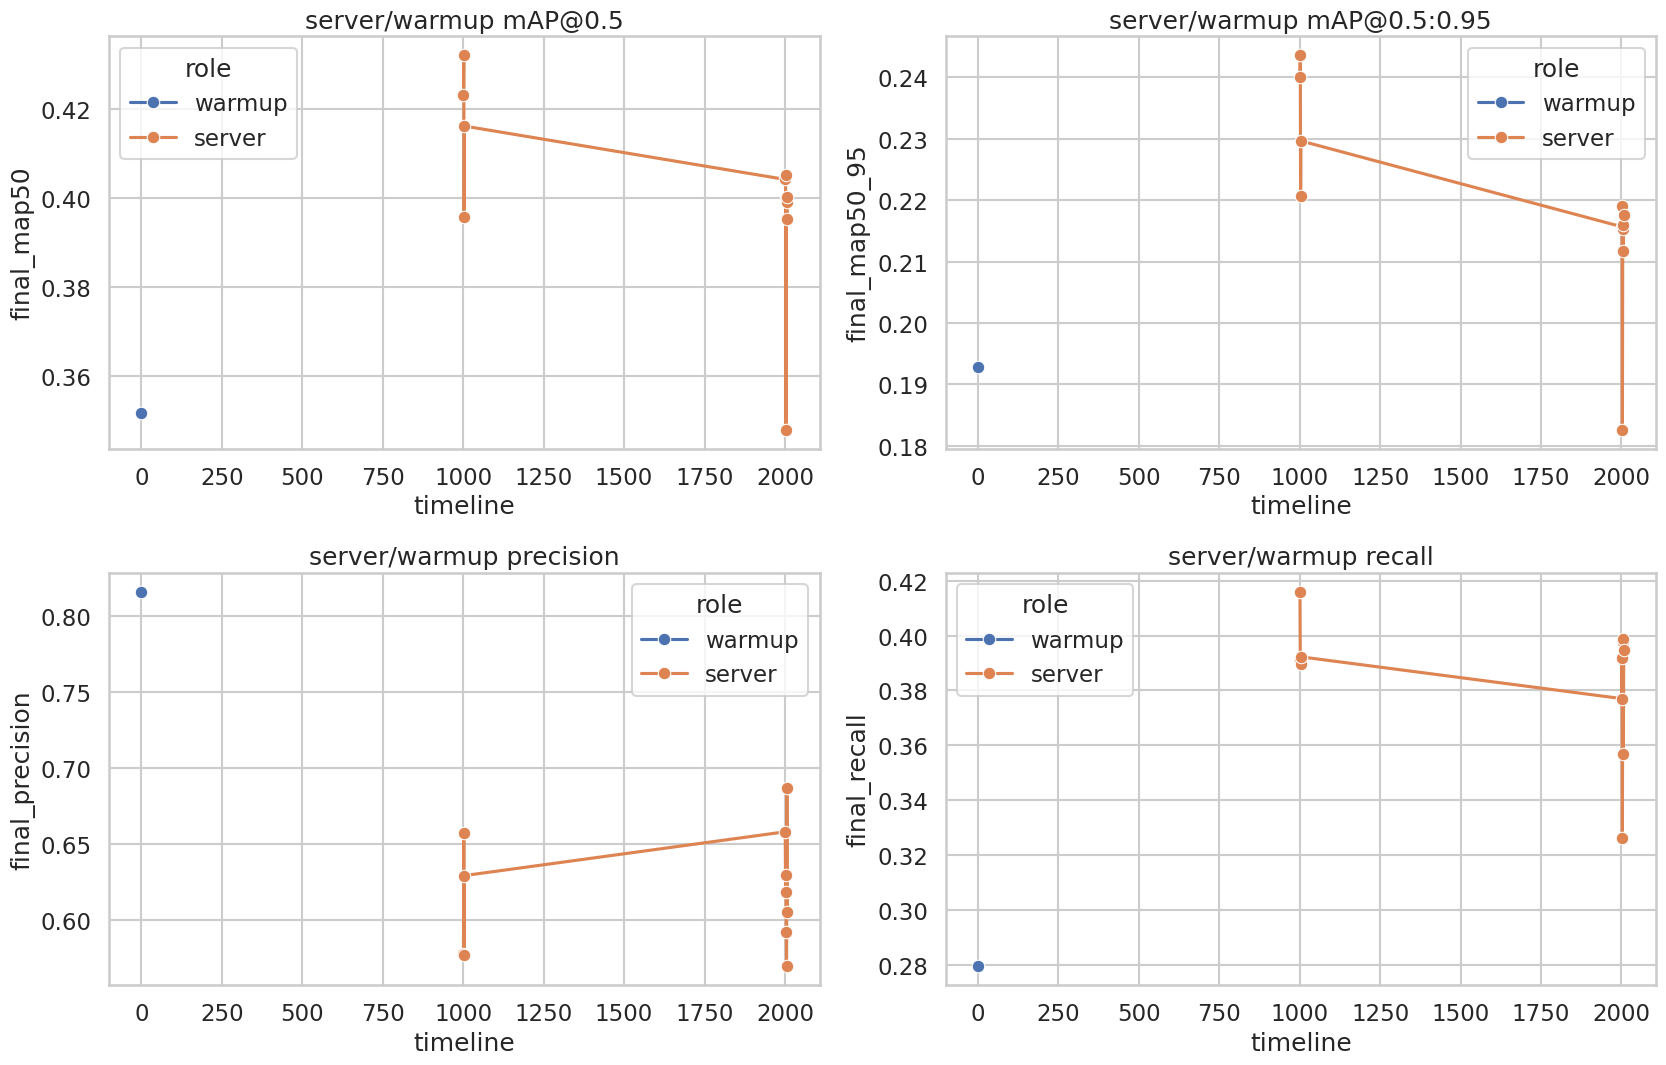

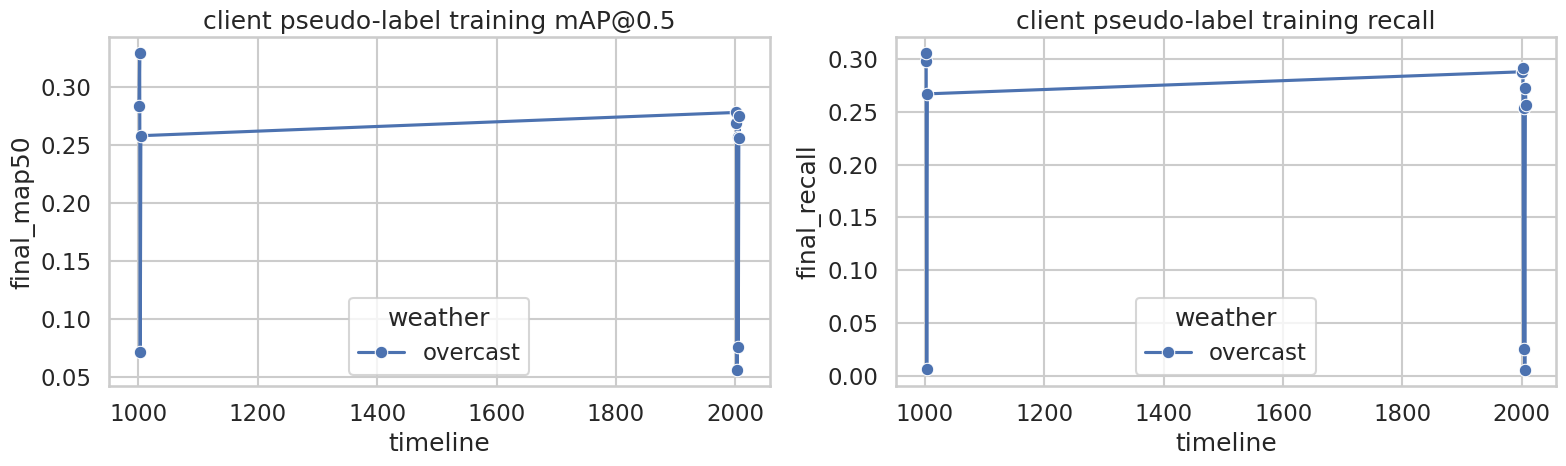

In [7]:
def plot_line(ax, data: pd.DataFrame, x: str, y: str, hue: str | None = None, marker: str = "o") -> None:
    if data.empty or y not in data:
        ax.set_title(f"missing {y}")
        return
    if sns is not None and hue is not None:
        sns.lineplot(data=data, x=x, y=y, hue=hue, marker=marker, ax=ax)
    elif sns is not None:
        sns.lineplot(data=data, x=x, y=y, marker=marker, ax=ax)
    else:
        for label, part in data.groupby(hue) if hue else [("", data)]:
            ax.plot(part[x], part[y], marker=marker, label=label)
        if hue:
            ax.legend()


if not summary_df.empty:
    curve_df = summary_df.copy()
    curve_df["timeline"] = np.where(
        curve_df["phase"] == 0,
        0,
        curve_df["phase"].astype(float) * 1000 + curve_df["round"].astype(float),
    )
    server_curve = curve_df[curve_df["role"].isin(["warmup", "server"])].copy()
    client_curve = curve_df[curve_df["role"].eq("client")].copy()

    fig, axes = plt.subplots(2, 2, figsize=(17, 11))
    plot_line(axes[0, 0], server_curve, "timeline", "final_map50", hue="role")
    plot_line(axes[0, 1], server_curve, "timeline", "final_map50_95", hue="role")
    plot_line(axes[1, 0], server_curve, "timeline", "final_precision", hue="role")
    plot_line(axes[1, 1], server_curve, "timeline", "final_recall", hue="role")
    axes[0, 0].set_title("server/warmup mAP@0.5")
    axes[0, 1].set_title("server/warmup mAP@0.5:0.95")
    axes[1, 0].set_title("server/warmup precision")
    axes[1, 1].set_title("server/warmup recall")
    plt.tight_layout()
    plt.show()

    if not client_curve.empty:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        plot_line(axes[0], client_curve, "timeline", "final_map50", hue="weather")
        plot_line(axes[1], client_curve, "timeline", "final_recall", hue="weather")
        axes[0].set_title("client pseudo-label training mAP@0.5")
        axes[1].set_title("client pseudo-label training recall")
        plt.tight_layout()
        plt.show()

## 4. ET vs LocalEMA Curves

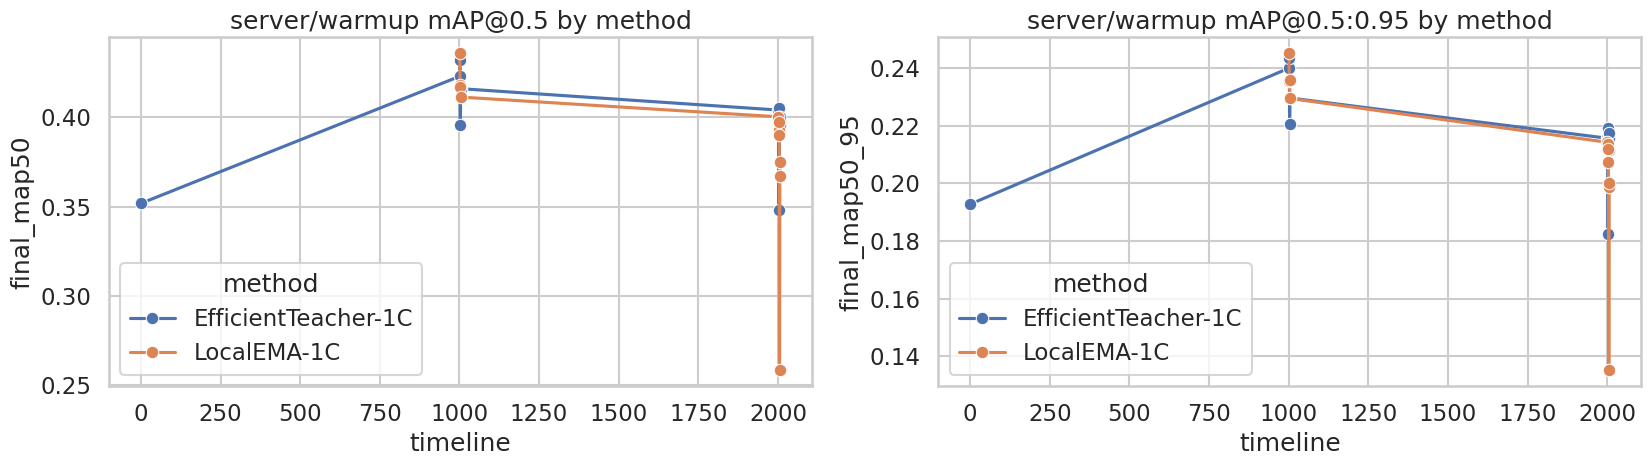

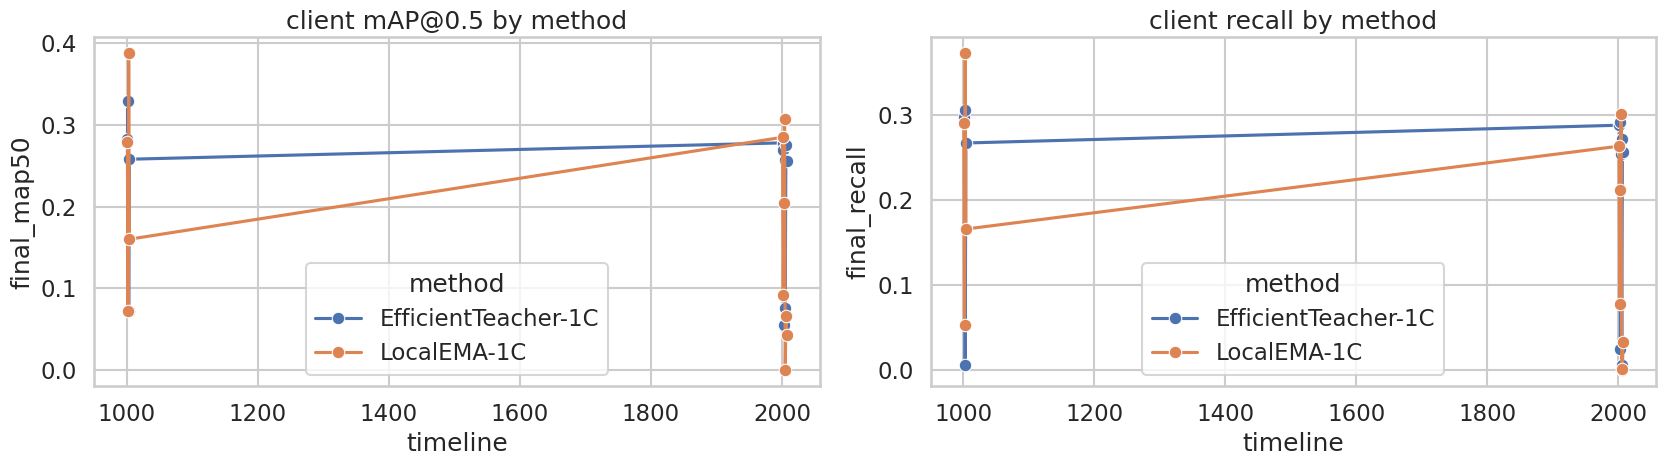

In [8]:
if not method_summary_df.empty:
    server_methods = method_summary_df[method_summary_df["role"].isin(["warmup", "server"])].copy()
    client_methods = method_summary_df[method_summary_df["role"].eq("client")].copy()
    if not server_methods.empty:
        fig, axes = plt.subplots(1, 2, figsize=(17, 5))
        plot_line(axes[0], server_methods, "timeline", "final_map50", hue="method")
        plot_line(axes[1], server_methods, "timeline", "final_map50_95", hue="method")
        axes[0].set_title("server/warmup mAP@0.5 by method")
        axes[1].set_title("server/warmup mAP@0.5:0.95 by method")
        plt.tight_layout()
        plt.show()
    if not client_methods.empty:
        fig, axes = plt.subplots(1, 2, figsize=(17, 5))
        plot_line(axes[0], client_methods, "timeline", "final_map50", hue="method")
        plot_line(axes[1], client_methods, "timeline", "final_recall", hue="method")
        axes[0].set_title("client mAP@0.5 by method")
        axes[1].set_title("client recall by method")
        plt.tight_layout()
        plt.show()

## 5. Loss Curves

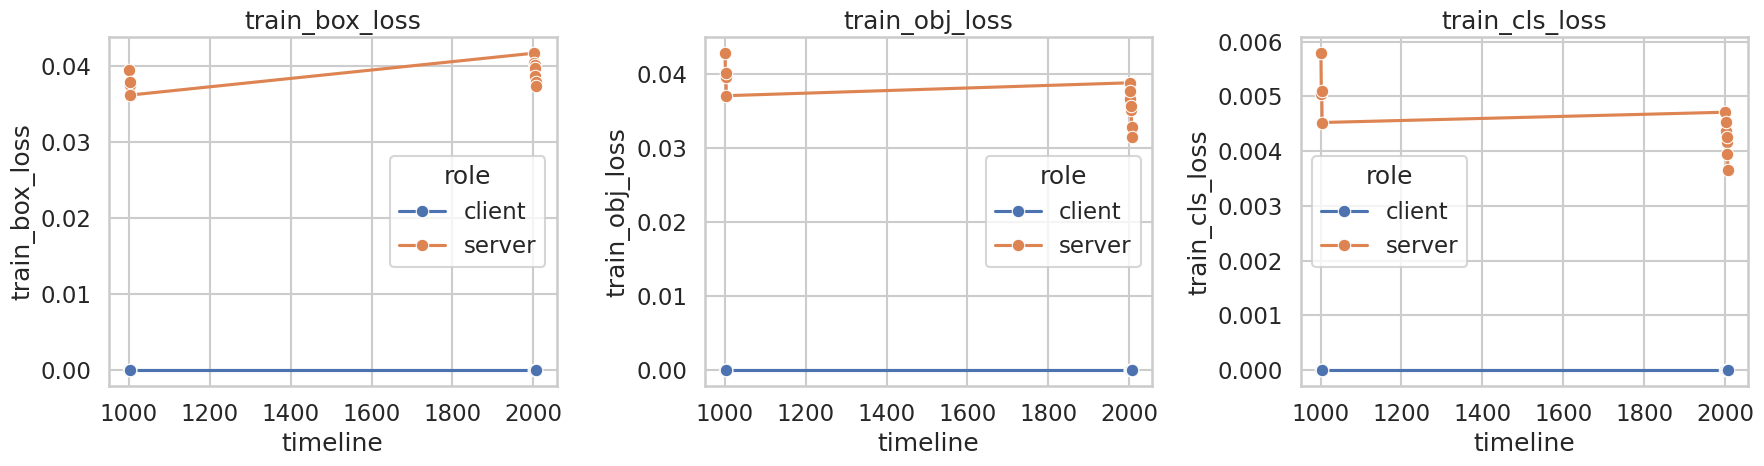

In [9]:
if not summary_df.empty:
    losses = ["train_box_loss", "train_obj_loss", "train_cls_loss"]
    plot_df = summary_df[summary_df["role"].isin(["client", "server"])].copy()
    plot_df["timeline"] = plot_df["phase"].astype(float) * 1000 + plot_df["round"].astype(float)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, loss_col in zip(axes, losses):
        plot_line(ax, plot_df, "timeline", loss_col, hue="role")
        ax.set_title(loss_col)
    plt.tight_layout()
    plt.show()

## 6. Pseudo-Label Stats

,method,phase,round,client,weather,file,total_pseudo,active_classes,weighted_confidence,weighted_quality,timeline
2,EfficientTeacher-1C,1,3,0,overcast,/app/Object_Detection/efficient_teacher/effici...,143943.0,9,0.5450,0.6687,1003
3,EfficientTeacher-1C,1,4,0,overcast,/app/Object_Detection/efficient_teacher/effici...,81601.0,9,0.5568,0.6868,1004
4,EfficientTeacher-1C,2,1,0,overcast,/app/Object_Detection/efficient_teacher/effici...,102280.0,9,0.5026,0.6488,2001
5,EfficientTeacher-1C,2,2,0,overcast,/app/Object_Detection/efficient_teacher/effici...,151756.0,9,0.7199,0.8009,2002
6,EfficientTeacher-1C,2,3,0,overcast,/app/Object_Detection/efficient_teacher/effici...,240439.0,9,0.4621,0.6187,2003
7,EfficientTeacher-1C,2,4,0,overcast,/app/Object_Detection/efficient_teacher/effici...,168215.0,9,0.5284,0.6679,2004
8,EfficientTeacher-1C,2,5,0,overcast,/app/Object_Detection/efficient_teacher/effici...,135343.0,9,0.5565,0.6863,2005
9,EfficientTeacher-1C,2,6,0,overcast,/app/Object_Detection/efficient_teacher/effici...,103065.0,9,0.5937,0.7125,2006
10,EfficientTeacher-1C,2,7,0,overcast,/app/Object_Detection/efficient_teacher/effici...,210433.0,9,0.4861,0.6346,2007
11,LocalEMA-1C,1,1,0,overcast,/app/Object_Detection/efficient_teacher/effici...,197514.0,9,0.3875,0.5648,1001


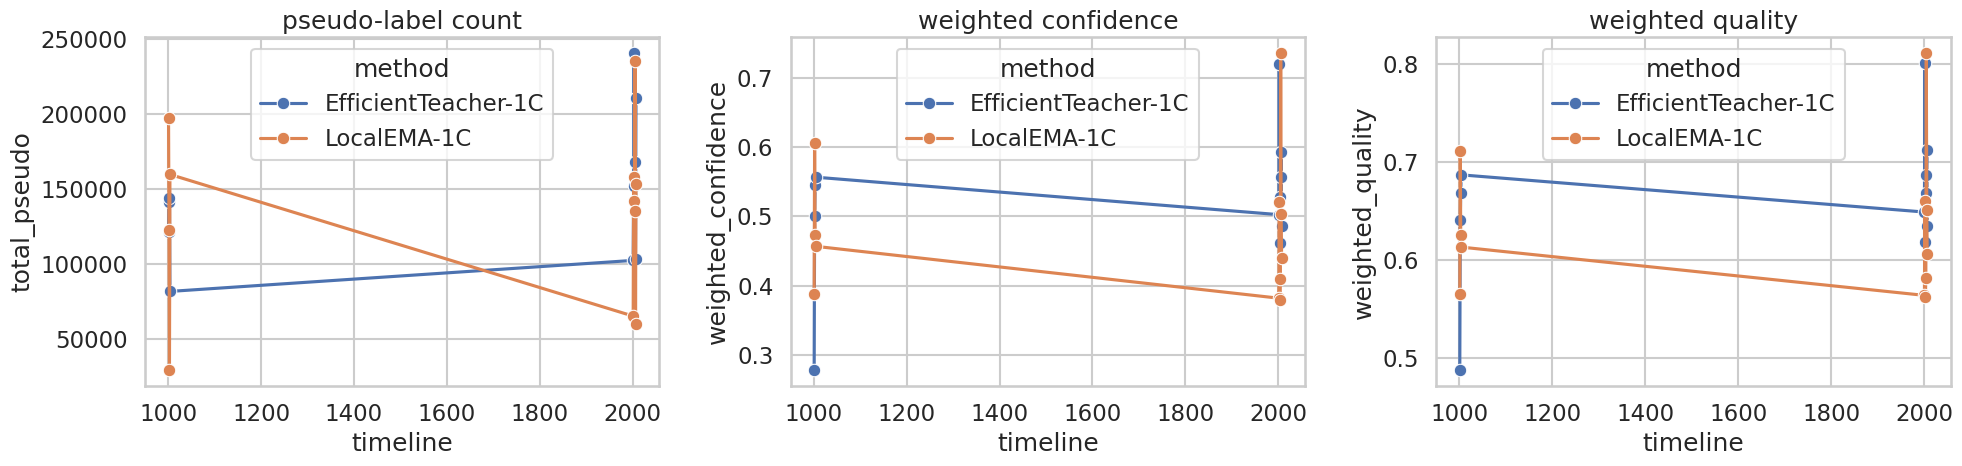

In [10]:
class_names = manifest.get("classes", [str(i) for i in range(10)])
pseudo_summary_rows = []
pseudo_class_rows = []
pattern = re.compile(r"phase(?P<phase>[12])_round(?P<round>\d{3})_client(?P<client>\d+)_(?P<weather>.+)\.json")

for method, workspace in METHOD_WORKSPACES.items():
    for path in sorted((workspace / "pseudo_stats").glob("phase*_round*_client*.json")):
        match = pattern.fullmatch(path.name)
        if not match:
            continue
        payload = json.loads(path.read_text(encoding="utf-8"))
        counts = np.array(payload.get("counts", []), dtype=float)
        mean_conf = np.array(payload.get("mean_confidences", [0] * len(counts)), dtype=float)
        mean_quality = np.array(payload.get("mean_quality_scores", mean_conf), dtype=float)
        total = counts.sum()
        weighted_conf = float((counts * mean_conf).sum() / total) if total > 0 else 0.0
        weighted_quality = float((counts * mean_quality).sum() / total) if total > 0 else 0.0
        meta = {
            "method": method,
            "phase": int(match.group("phase")),
            "round": int(match.group("round")),
            "client": int(match.group("client")),
            "weather": match.group("weather"),
            "file": str(path),
        }
        pseudo_summary_rows.append(
            {
                **meta,
                "total_pseudo": float(total),
                "active_classes": int((counts > 0).sum()),
                "weighted_confidence": weighted_conf,
                "weighted_quality": weighted_quality,
            }
        )
        for class_idx, count in enumerate(counts):
            pseudo_class_rows.append(
                {
                    **meta,
                    "class_idx": class_idx,
                    "class_name": class_names[class_idx] if class_idx < len(class_names) else str(class_idx),
                    "count": float(count),
                    "mean_confidence": float(mean_conf[class_idx]) if class_idx < len(mean_conf) else 0.0,
                    "mean_quality": float(mean_quality[class_idx]) if class_idx < len(mean_quality) else 0.0,
                }
            )

pseudo_summary = pd.DataFrame(pseudo_summary_rows)
pseudo_by_class = pd.DataFrame(pseudo_class_rows)
if not pseudo_summary.empty:
    pseudo_summary["timeline"] = pseudo_summary["phase"] * 1000 + pseudo_summary["round"]
    pseudo_summary.to_csv(tables_root / "pseudo_label_round_summary.csv", index=False)
    pseudo_by_class.to_csv(tables_root / "pseudo_label_class_summary.csv", index=False)
    display(pseudo_summary.tail(20).round(4))

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plot_line(axes[0], pseudo_summary, "timeline", "total_pseudo", hue="method")
    plot_line(axes[1], pseudo_summary, "timeline", "weighted_confidence", hue="method")
    plot_line(axes[2], pseudo_summary, "timeline", "weighted_quality", hue="method")
    axes[0].set_title("pseudo-label count")
    axes[1].set_title("weighted confidence")
    axes[2].set_title("weighted quality")
    plt.tight_layout()
    plt.show()
else:
    print("No pseudo-label stats found yet.")

## 7. Class-Wise Pseudo-Label Heatmap

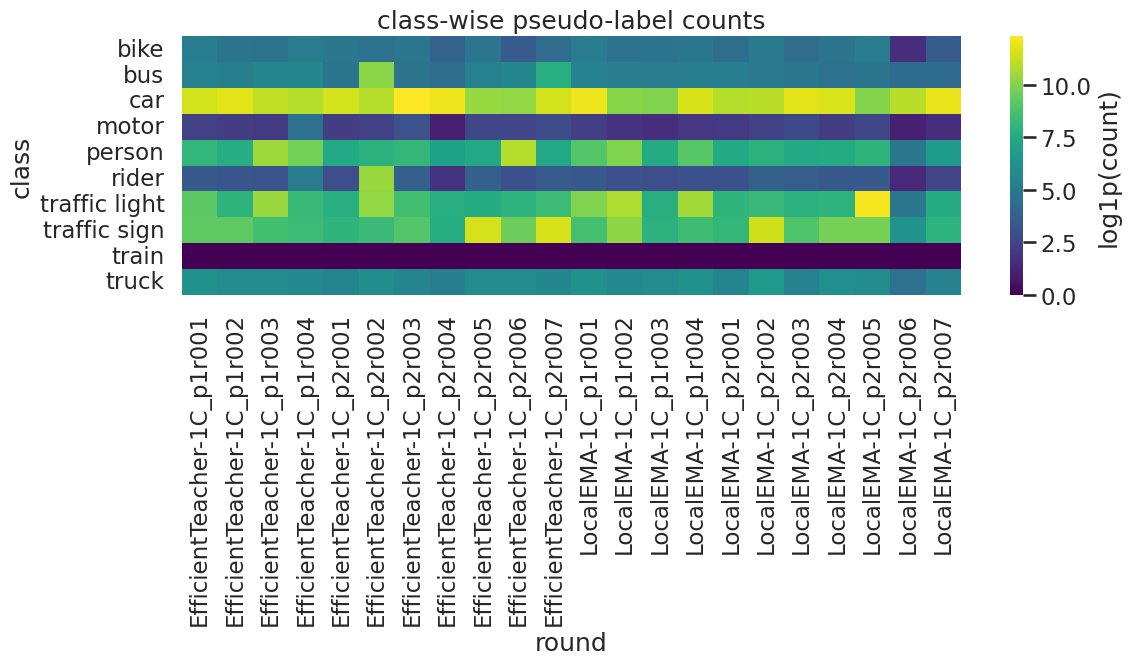

In [11]:
if not pseudo_by_class.empty:
    heatmap_df = pseudo_by_class.copy()
    heatmap_df["round_label"] = (
        heatmap_df["method"].astype(str)
        + "_p"
        + heatmap_df["phase"].astype(str)
        + "r"
        + heatmap_df["round"].astype(str).str.zfill(3)
    )
    pivot = heatmap_df.pivot_table(index="class_name", columns="round_label", values="count", aggfunc="sum", fill_value=0)
    plt.figure(figsize=(max(12, 0.35 * pivot.shape[1]), 7))
    if sns is not None:
        sns.heatmap(np.log1p(pivot), cmap="viridis", cbar_kws={"label": "log1p(count)"})
    else:
        plt.imshow(np.log1p(pivot), aspect="auto", cmap="viridis")
        plt.colorbar(label="log1p(count)")
        plt.yticks(range(len(pivot.index)), pivot.index)
        plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
    plt.title("class-wise pseudo-label counts")
    plt.xlabel("round")
    plt.ylabel("class")
    plt.tight_layout()
    plt.show()

## 8. Paper-Protocol Evaluation

Set `RUN_PAPER_EVAL = True` to run the shared per-weather validation for warmup, phase1 final, phase2 best, and phase2 final checkpoints.

In [12]:
RUN_PAPER_EVAL = False
PAPER_EVAL_SPLITS = "cloudy,overcast,rainy,snowy,total"
PAPER_EVAL_BATCH_SIZE = 8

eval_cmds = [
    [
        str(PYTHON_BIN),
        str(EVAL_SCRIPT),
        "--workspace",
        str(workspace),
        "--splits",
        PAPER_EVAL_SPLITS,
        "--batch-size",
        str(PAPER_EVAL_BATCH_SIZE),
    ]
    for workspace in METHOD_WORKSPACES.values()
    if workspace.exists()
]
if RUN_PAPER_EVAL:
    for eval_cmd in eval_cmds:
        subprocess.run(eval_cmd, cwd=REPO_ROOT, check=True)
else:
    print("Set RUN_PAPER_EVAL = True to run:")
    for eval_cmd in eval_cmds:
        print(" ".join(eval_cmd))

Set RUN_PAPER_EVAL = True to run:
/root/micromamba/envs/al_yolov8/bin/python /app/Object_Detection/efficient_teacher/evaluate_paper_protocol.py --workspace /app/Object_Detection/efficient_teacher/efficientteacher_single_client --splits cloudy,overcast,rainy,snowy,total --batch-size 8
/root/micromamba/envs/al_yolov8/bin/python /app/Object_Detection/efficient_teacher/evaluate_paper_protocol.py --workspace /app/Object_Detection/efficient_teacher/efficientteacher_localema --splits cloudy,overcast,rainy,snowy,total --batch-size 8


## 9. Paper-Protocol Results

In [13]:
paper_summary_path = VALIDATION_ROOT / "paper_protocol_eval_summary.csv"
paper_frames = []
for method, workspace in METHOD_WORKSPACES.items():
    path = workspace / "validation_reports" / "paper_protocol_eval_summary.csv"
    if path.exists():
        df = pd.read_csv(path)
        df.insert(0, "method", method)
        paper_frames.append(df)

if paper_frames:
    paper_df = pd.concat(paper_frames, ignore_index=True)
    display(paper_df.round(4))
    ok_rows = paper_df[paper_df["status"].eq("ok")].copy()
    if not ok_rows.empty:
        fig, axes = plt.subplots(1, 2, figsize=(17, 5))
        if sns is not None:
            sns.barplot(data=ok_rows, x="split", y="map50", hue="method", ax=axes[0])
            sns.barplot(data=ok_rows, x="split", y="map50_95", hue="method", ax=axes[1])
        else:
            ok_rows.pivot_table(index="split", columns="method", values="map50").plot(kind="bar", ax=axes[0])
            ok_rows.pivot_table(index="split", columns="method", values="map50_95").plot(kind="bar", ax=axes[1])
        axes[0].set_title("paper eval mAP@0.5")
        axes[1].set_title("paper eval mAP@0.5:0.95")
        for ax in axes:
            ax.tick_params(axis="x", rotation=20)
        plt.tight_layout()
        plt.show()
else:
    print("No ET/LocalEMA paper-protocol summary CSVs yet.")

,method,checkpoint_label,checkpoint_path,split,split_list,status,returncode,images,labels,precision,recall,map50,map50_95,log_file,command,error
0,EfficientTeacher-1C,warmup_global,/app/Object_Detection/efficient_teacher/effici...,cloudy,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
1,EfficientTeacher-1C,warmup_global,/app/Object_Detection/efficient_teacher/effici...,overcast,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
2,EfficientTeacher-1C,warmup_global,/app/Object_Detection/efficient_teacher/effici...,rainy,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
3,EfficientTeacher-1C,warmup_global,/app/Object_Detection/efficient_teacher/effici...,snowy,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
4,EfficientTeacher-1C,warmup_global,/app/Object_Detection/efficient_teacher/effici...,total,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
5,EfficientTeacher-1C,phase1_round004_global,/app/Object_Detection/efficient_teacher/effici...,cloudy,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
6,EfficientTeacher-1C,phase1_round004_global,/app/Object_Detection/efficient_teacher/effici...,overcast,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
7,EfficientTeacher-1C,phase1_round004_global,/app/Object_Detection/efficient_teacher/effici...,rainy,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
8,EfficientTeacher-1C,phase1_round004_global,/app/Object_Detection/efficient_teacher/effici...,snowy,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
9,EfficientTeacher-1C,phase1_round004_global,/app/Object_Detection/efficient_teacher/effici...,total,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."


## 10. Optional Comparison with LocalEMA, DQA, and FedSTO

,method,checkpoint_label,checkpoint_path,split,split_list,status,returncode,images,labels,precision,recall,map50,map50_95,log_file,command,error
0,EfficientTeacher-1C,warmup_global,/app/Object_Detection/efficient_teacher/effici...,cloudy,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
1,EfficientTeacher-1C,warmup_global,/app/Object_Detection/efficient_teacher/effici...,overcast,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
2,EfficientTeacher-1C,warmup_global,/app/Object_Detection/efficient_teacher/effici...,rainy,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
3,EfficientTeacher-1C,warmup_global,/app/Object_Detection/efficient_teacher/effici...,snowy,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
4,EfficientTeacher-1C,warmup_global,/app/Object_Detection/efficient_teacher/effici...,total,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
5,EfficientTeacher-1C,phase1_round004_global,/app/Object_Detection/efficient_teacher/effici...,cloudy,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
6,EfficientTeacher-1C,phase1_round004_global,/app/Object_Detection/efficient_teacher/effici...,overcast,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
7,EfficientTeacher-1C,phase1_round004_global,/app/Object_Detection/efficient_teacher/effici...,rainy,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
8,EfficientTeacher-1C,phase1_round004_global,/app/Object_Detection/efficient_teacher/effici...,snowy,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."
9,EfficientTeacher-1C,phase1_round004_global,/app/Object_Detection/efficient_teacher/effici...,total,/app/Object_Detection/efficient_teacher/effici...,failed,1,NaN,NaN,NaN,NaN,NaN,NaN,/app/Object_Detection/efficient_teacher/effici...,/root/micromamba/envs/al_yolov8/bin/python val...,"ontext\n return func(*args, **kwargs)\n Fi..."


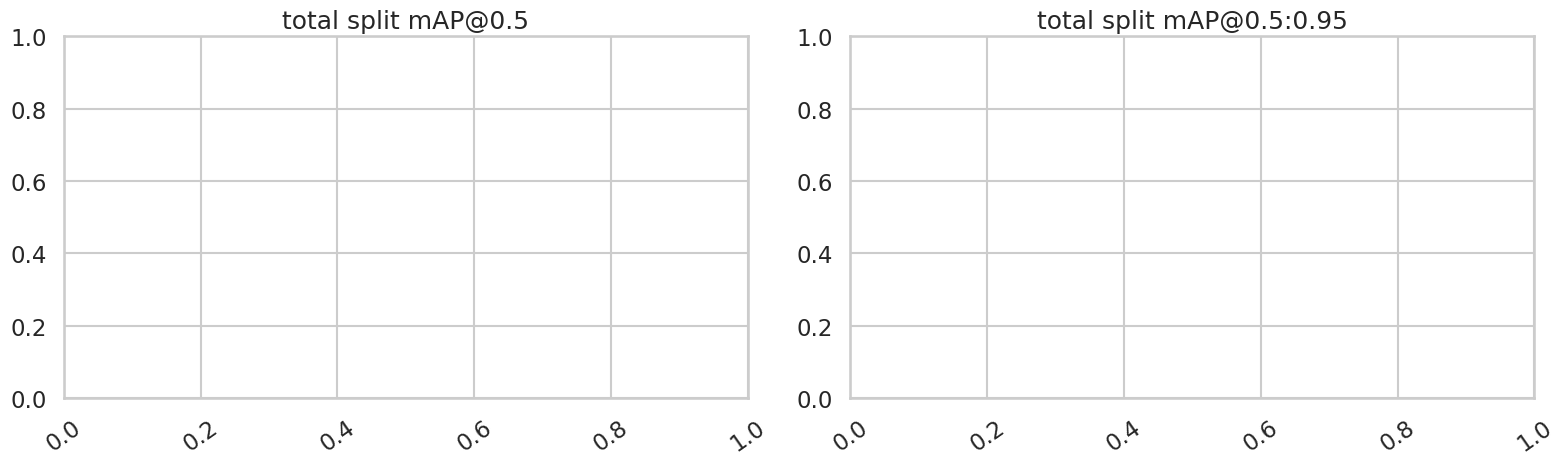

In [14]:
frames = []
for method, path in [
    ("EfficientTeacher-1C", paper_summary_path),
    ("LocalEMA-1C", LOCALEMA_WORK_ROOT / "validation_reports" / "paper_protocol_eval_summary.csv"),
    ("DQA-CWA", DQA_PAPER_EVAL),
    ("FedSTO", FEDSTO_PAPER_EVAL),
]:
    if path.exists():
        df = pd.read_csv(path)
        df.insert(0, "method", method)
        frames.append(df)

if frames:
    comparison = pd.concat(frames, ignore_index=True)
    display(comparison.round(4))
    ok = comparison[comparison["status"].eq("ok")].copy()
    if not ok.empty:
        total = ok[ok["split"].eq("total")].copy()
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        if sns is not None:
            sns.barplot(data=total, x="checkpoint_label", y="map50", hue="method", ax=axes[0])
            sns.barplot(data=total, x="checkpoint_label", y="map50_95", hue="method", ax=axes[1])
        else:
            total.pivot(index="checkpoint_label", columns="method", values="map50").plot(kind="bar", ax=axes[0])
            total.pivot(index="checkpoint_label", columns="method", values="map50_95").plot(kind="bar", ax=axes[1])
        axes[0].set_title("total split mAP@0.5")
        axes[1].set_title("total split mAP@0.5:0.95")
        for ax in axes:
            ax.tick_params(axis="x", rotation=35)
        plt.tight_layout()
        plt.show()
else:
    print("No paper-eval summaries found for comparison yet.")

## 11. Validation Plot Artifacts

,method,run,PR_curve,F1_curve,P_curve,R_curve,confusion_matrix
0,EfficientTeacher-1C,phase1_round004_global_cloudy,True,True,True,True,True
1,EfficientTeacher-1C,phase1_round004_global_overcast,True,True,True,True,True
2,EfficientTeacher-1C,phase1_round004_global_rainy,True,True,True,True,True
3,EfficientTeacher-1C,phase1_round004_global_snowy,True,True,True,True,True
4,EfficientTeacher-1C,phase1_round004_global_total,True,True,True,True,True
5,EfficientTeacher-1C,phase2_round001_global_cloudy,True,True,True,True,True
6,EfficientTeacher-1C,phase2_round001_global_overcast,True,True,True,True,True
7,EfficientTeacher-1C,phase2_round001_global_rainy,True,True,True,True,True
8,EfficientTeacher-1C,phase2_round001_global_snowy,True,True,True,True,True
9,EfficientTeacher-1C,phase2_round001_global_total,False,False,False,False,False


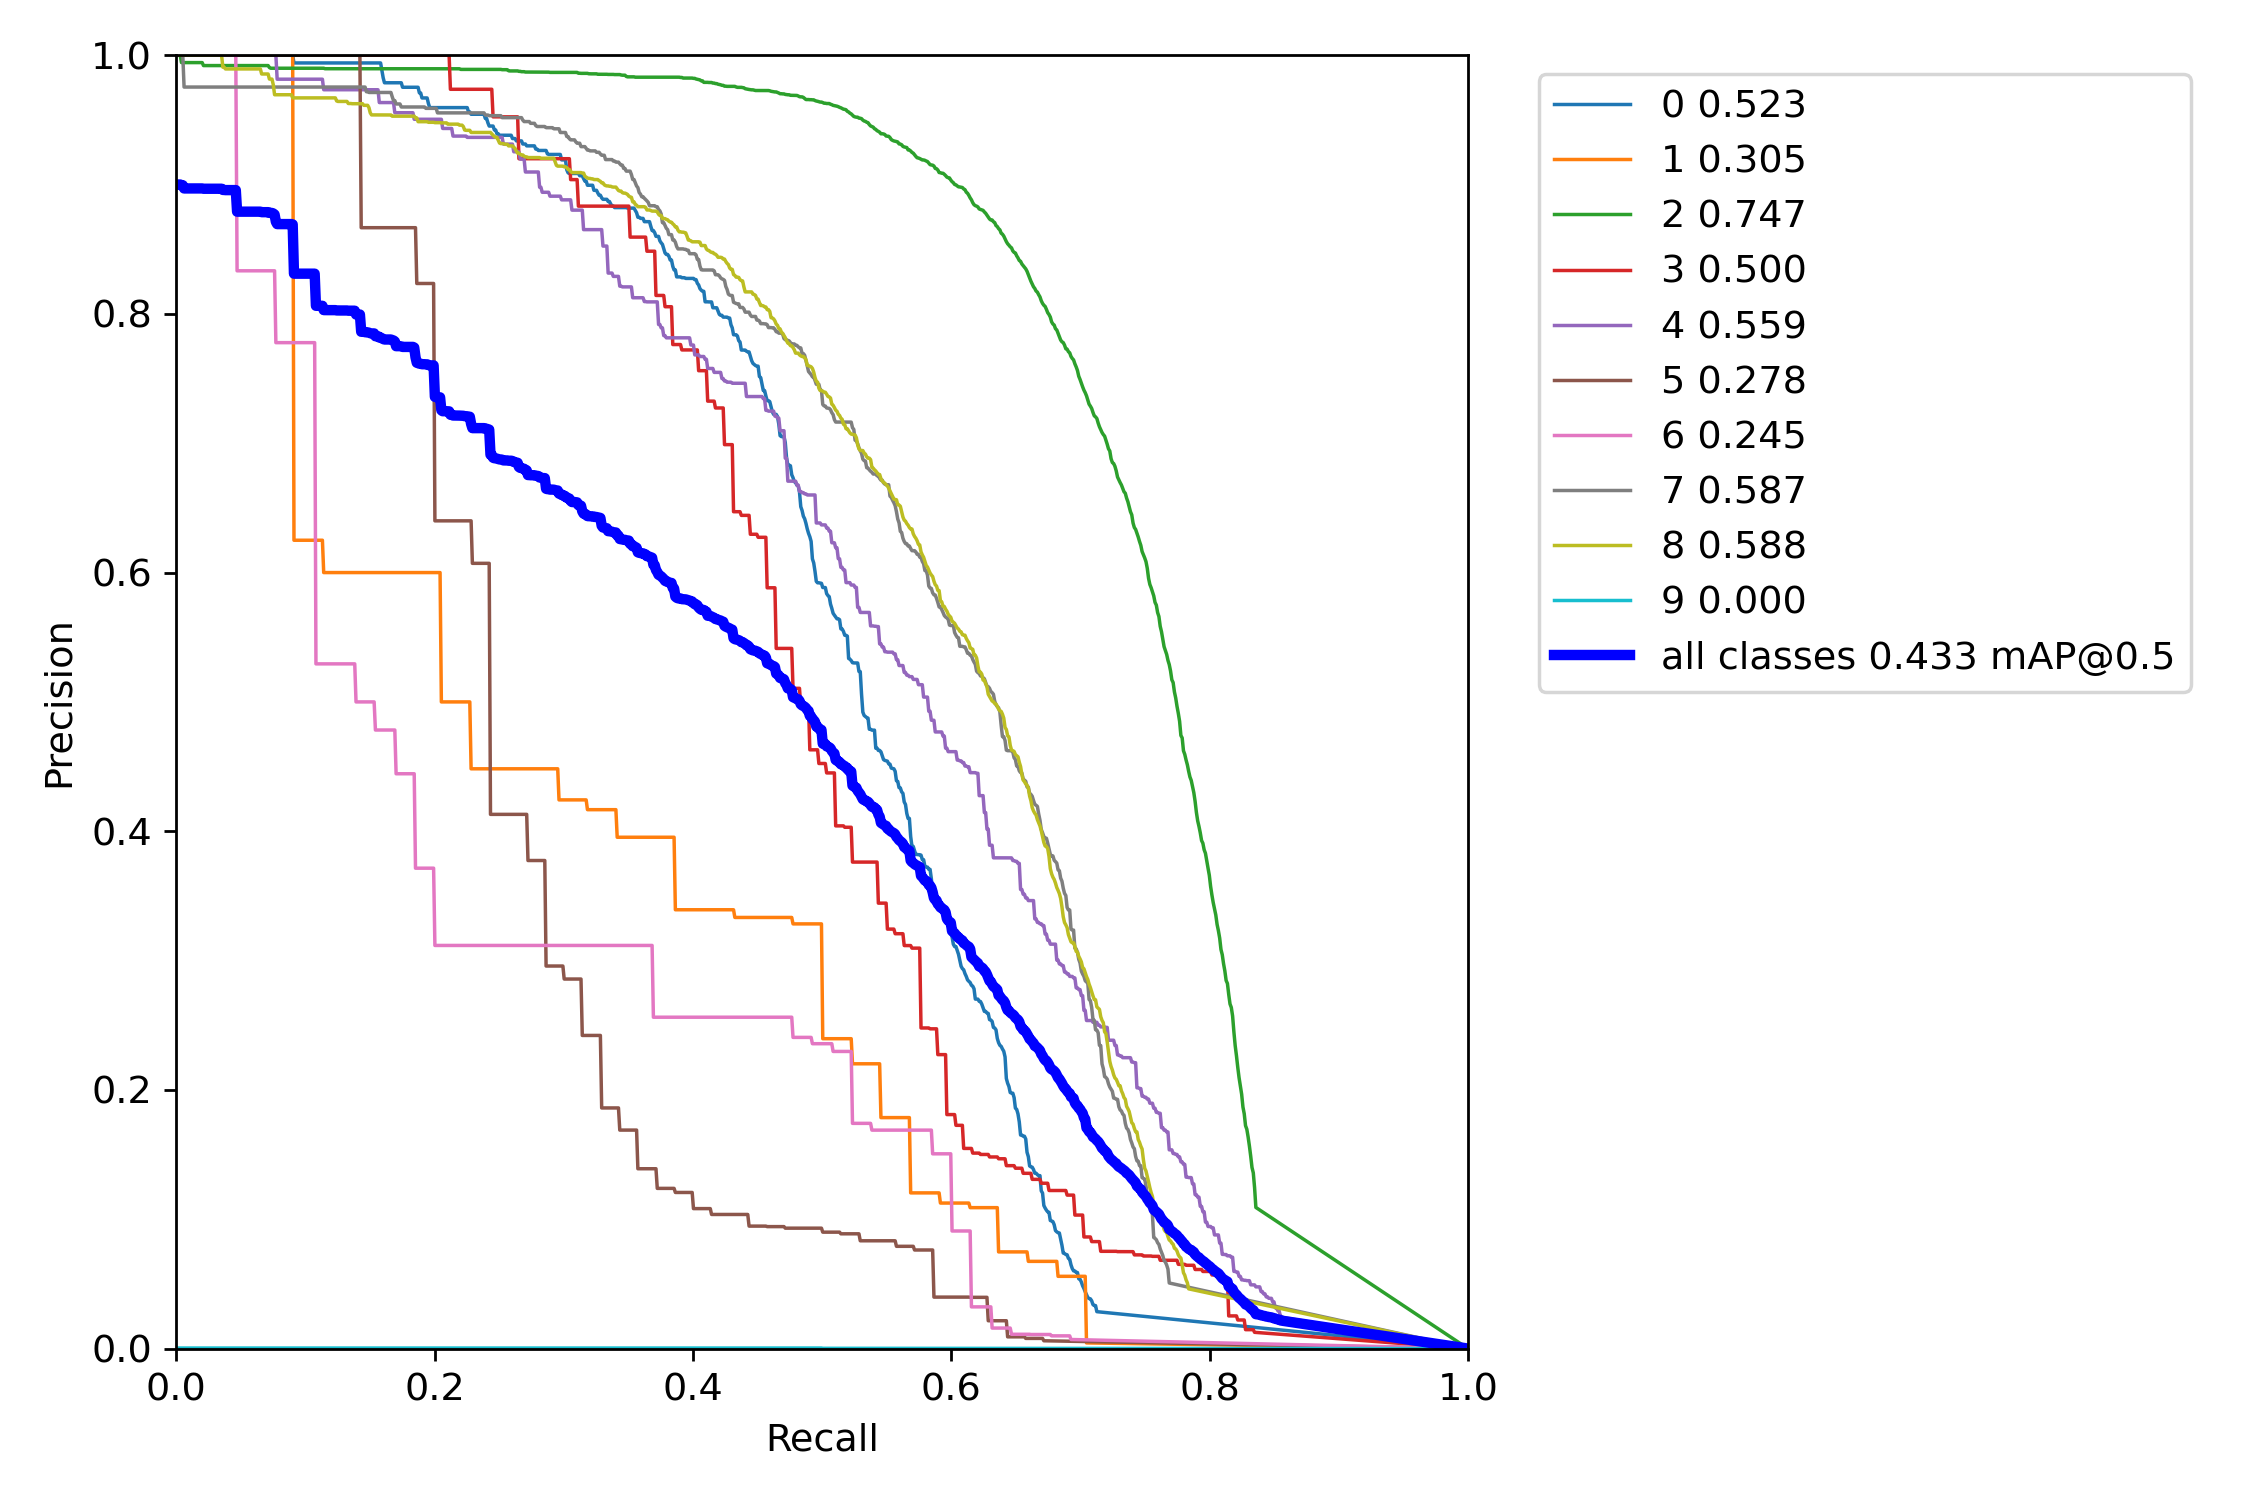

In [15]:
plot_rows = []
for method, workspace in METHOD_WORKSPACES.items():
    val_runs = workspace / "validation_reports" / "paper_protocol_val_runs"
    for run_dir in sorted(val_runs.glob("*")):
        if not run_dir.is_dir():
            continue
        plot_rows.append(
            {
                "method": method,
                "run": run_dir.name,
                "PR_curve": (run_dir / "PR_curve.png").exists(),
                "F1_curve": (run_dir / "F1_curve.png").exists(),
                "P_curve": (run_dir / "P_curve.png").exists(),
                "R_curve": (run_dir / "R_curve.png").exists(),
                "confusion_matrix": (run_dir / "confusion_matrix.png").exists(),
            }
        )
display(pd.DataFrame(plot_rows) if plot_rows else pd.DataFrame())

first_pr = None
for workspace in METHOD_WORKSPACES.values():
    val_runs = workspace / "validation_reports" / "paper_protocol_val_runs"
    first_pr = next(val_runs.glob("*/PR_curve.png"), None) if val_runs.exists() else None
    if first_pr is not None:
        break
if first_pr is not None:
    display(NotebookImage(filename=str(first_pr)))